In [1]:
%load_ext autoreload
%autoreload 2

# Model Training: New Multiclass Classification Task

`Task Description: Predict the first service a client will use in the next 30 days.`

In [2]:
import gc
import os
from warnings import filterwarnings

filterwarnings("ignore")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [3]:
import torch
from relbench.datasets import get_dataset
from relbench.modeling.graph import make_pkey_fkey_graph
from relbench.modeling.utils import get_stype_proposal
from torch_frame.config.text_embedder import TextEmbedderConfig
from torch_geometric import seed_everything

In [4]:
from experiments.model_training.training.models.hgt_model import HGTModel
from experiments.model_training.training.models.sage_model import SAGEModel
from experiments.model_training.training.text_embedder import TextEmbedder
from experiments.model_training.training.trainer import Trainer
from experiments.model_training.utils import (
    get_device,
    load_config,
    make_loaders,
    patched_to_unix_time,
)

In [5]:
import relbench.modeling.graph
import relbench.modeling.utils

relbench.modeling.graph.to_unix_time = patched_to_unix_time
relbench.modeling.utils.to_unix_time = patched_to_unix_time

In [6]:
from predql_tasks.tasks import SeznamClientFirstServisTmpTask

In [7]:
seed_everything(42)
device = get_device()
config = load_config("config.yml")
cache_dir = "./.cache_predql"
dataset_name = "ctu-seznam"
task_name = "seznam_client_first_servis_tmp"

Using device: cuda


In [8]:
dataset = get_dataset(dataset_name, download=False)
task = SeznamClientFirstServisTmpTask()
db = dataset.get_db()

Loading Database object from /home/kolesiko/.cache/relbench/ctu-seznam/db...
Done in 0.19 seconds.


In [9]:
col_to_stype_dict = get_stype_proposal(db)
col_to_stype_dict

{'probehnuto_mimo_penezenku': {'__PK__': <stype.numerical: 'numerical'>,
  'client_id': <stype.numerical: 'numerical'>,
  'Month_Year': <stype.timestamp: 'timestamp'>,
  'probehla_inzerce_mimo_penezenku': <stype.categorical: 'categorical'>,
  'FK_client_client_id': <stype.numerical: 'numerical'>},
 'dobito': {'__PK__': <stype.numerical: 'numerical'>,
  'client_id': <stype.numerical: 'numerical'>,
  'month_year_datum_transakce': <stype.timestamp: 'timestamp'>,
  'sluzba': <stype.categorical: 'categorical'>,
  'kc_dobito': <stype.numerical: 'numerical'>,
  'FK_client_client_id': <stype.numerical: 'numerical'>},
 'probehnuto': {'__PK__': <stype.numerical: 'numerical'>,
  'client_id': <stype.numerical: 'numerical'>,
  'month_year_datum_transakce': <stype.timestamp: 'timestamp'>,
  'sluzba': <stype.categorical: 'categorical'>,
  'kc_proklikano': <stype.numerical: 'numerical'>,
  'FK_client_client_id': <stype.numerical: 'numerical'>},
 'client': {'__PK__': <stype.numerical: 'numerical'>,
  '

In [10]:
model_name = config["shared"]["text_embedder_model_name"]
batch_size = config["shared"]["batch_size"]

In [11]:
text_embedder = TextEmbedderConfig(
    text_embedder=TextEmbedder(
        model_name=model_name,
        device="cpu",
        cache_dir=cache_dir), batch_size=batch_size
)

data, col_stats_dict = make_pkey_fkey_graph(
    db,
    col_to_stype_dict,
    text_embedder,
    cache_dir=os.path.join(cache_dir, dataset_name)
)

data


HeteroData(
  probehnuto_mimo_penezenku={
    tf=TensorFrame([588990, 3]),
    time=[588990],
  },
  dobito={
    tf=TensorFrame([501626, 4]),
    time=[501626],
  },
  probehnuto={
    tf=TensorFrame([1321324, 4]),
    time=[1321324],
  },
  client={ tf=TensorFrame([73447, 2]) },
  (probehnuto_mimo_penezenku, f2p_FK_client_client_id, client)={ edge_index=[2, 588990] },
  (client, rev_f2p_FK_client_client_id, probehnuto_mimo_penezenku)={ edge_index=[2, 588990] },
  (dobito, f2p_FK_client_client_id, client)={ edge_index=[2, 501396] },
  (client, rev_f2p_FK_client_client_id, dobito)={ edge_index=[2, 501396] },
  (probehnuto, f2p_FK_client_client_id, client)={ edge_index=[2, 1321023] },
  (client, rev_f2p_FK_client_client_id, probehnuto)={ edge_index=[2, 1321023] }
)

In [12]:
loader_dict, _, le = make_loaders(
    data,
    task,
    batch_size,
    num_neighbors=config["shared"]["num_neighbors"],
    encode=True
)

Loading Database object from /home/kolesiko/.cache/relbench/ctu-seznam/db...
Done in 0.11 seconds.
Loading Database object from /home/kolesiko/.cache/relbench/ctu-seznam/db...
Done in 0.12 seconds.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [13]:
out_channels = len(le.classes_)
print(f"Number of classes: {out_channels}")

Number of classes: 8


In [14]:
task_type = task.task_type

in_channels = config["shared"]["in_channels"]
learning_rate = config["shared"]["learning_rate"]
dropout = config["shared"]["dropout"]
num_epochs = config["shared"]["num_epochs"]
num_runs = config["shared"]["num_runs"]

mlp_config = config["mlp_head"]
mlp_config["out_channels"] = out_channels

## SAGE


MODEL INFO:
Model name: SAGE
Number of parameters: 1771016


STARTING RUN 1/5


Evaluating: 100%|██████████| 282/282 [00:03<00:00, 90.00it/s]


Epoch 1/30 | Train Loss: 0.9903 | Train accuracy: 0.5626
Epoch 1/30 |   Val Loss: 1.1228 |   Val accuracy: 0.4145
New best model found with Val accuracy: 0.4145


Evaluating: 100%|██████████| 282/282 [00:03<00:00, 84.19it/s]


New best model found with Val accuracy: 0.4202


...

Evaluating: 100%|██████████| 282/282 [00:03<00:00, 86.40it/s]


Epoch 21/30 | Train Loss: 0.9360 | Train accuracy: 0.5718
Epoch 21/30 |   Val Loss: 1.0855 |   Val accuracy: 0.4217
!!! No improvement in Val accuracy for 10 epochs (Early stopping at epoch 21) !!!


Evaluating: 100%|██████████| 271/271 [00:03<00:00, 88.69it/s]


Run 5/5 | Final Train Metrics: {'accuracy': 0.5706966202381497, 'macro_f1': 0.2637231192238662, 'micro_f1': 0.5706966202381497, 'loss': 0.933458776861794}
Run 5/5 | Final Val Metrics: {'accuracy': 0.4425933387986494, 'macro_f1': 0.38607653616816084, 'micro_f1': 0.4425933387986494, 'loss': 1.0880653078982185}
Run 5/5 | Final Test Metrics: {'accuracy': 0.46890380313199104, 'macro_f1': 0.39295155050906194, 'micro_f1': 0.46890380313199104, 'loss': 1.0406768581985422}
FINISHED RUN 5/5


FINAL STATS OVER 5 RUNS

[TRAIN] Metrics:
  Accuracy: 0.5698 ± 0.0011
  Macro_f1: 0.2613 ± 0.0051
  Micro_f1: 0.5698 ± 0.0011
  Loss: 0.9361 ± 0.0039

[VAL] Metrics:
  Accuracy: 0.4417 ± 0.0058
  Macro_f1: 0.3834 ± 0.0090
  Micro_f1: 0.4417 ± 0.0058
  Loss: 1.0835 ± 0.0188

[TEST] Metrics:
  Accuracy: 0.4677 ± 0.0056
  Macro_f1: 0.3899 ± 0.0096
  Micro_f1: 0.4677 ± 0.0056
  Loss: 1.0380 ± 0.0155



15

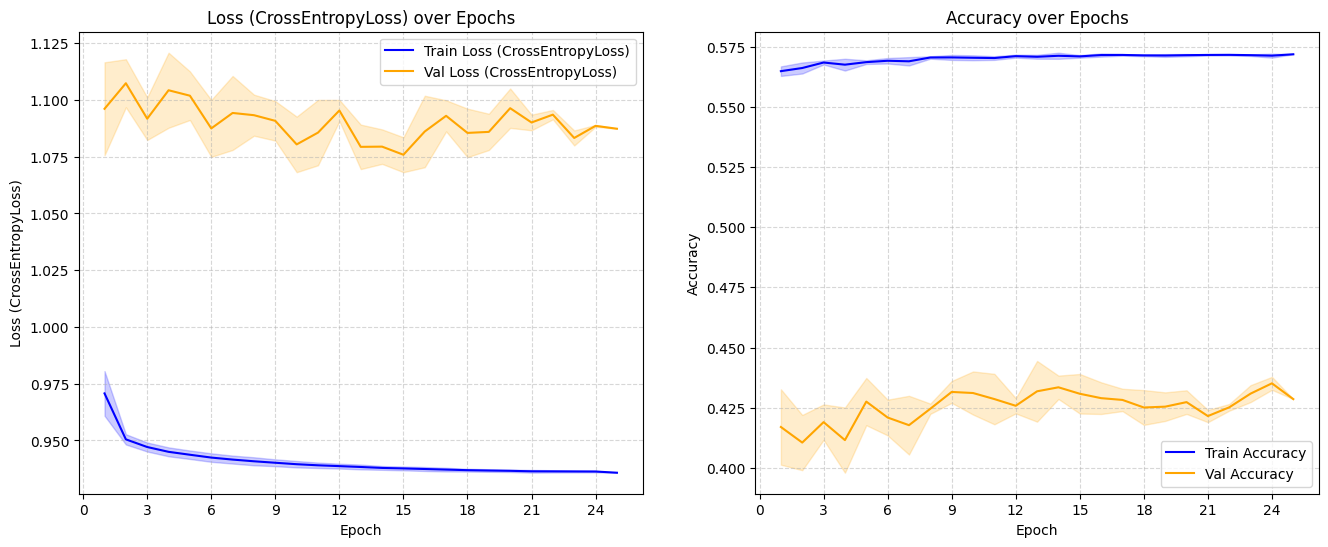

In [15]:
sage_model = SAGEModel(
    data=data,
    col_stats_dict=col_stats_dict,
    in_channels=in_channels,
    gnn_config=config["gnn_heads"]["sage"],
    mlp_config=mlp_config,
    task_type=task_type,
    dropout=dropout
).to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(sage_model.parameters(), lr=learning_rate)

trainer = Trainer(
    task=task,
    model=sage_model,
    optimizer=optimizer,
    criterion=criterion,
    device=device
)

trainer.run_experiment(
    loader_dict,
    num_epochs,
    tune_metric="accuracy",
    higher_is_better=True,
    patience=10,
    print_every=3,
    num_runs=num_runs
)

# torch.save(best_weights, os.path.join(cache_dir, dataset_name, f"{sage_model.gnn_name}_{task_name}_best_weights.pt"))

del sage_model, optimizer, trainer
torch.cuda.empty_cache()
gc.collect()

## HGT


MODEL INFO:
Model name: HGT
Number of parameters: 2266424


STARTING RUN 1/5


Evaluating: 100%|██████████| 282/282 [00:04<00:00, 67.06it/s]


Epoch 1/30 | Train Loss: 1.0406 | Train accuracy: 0.5586
Epoch 1/30 |   Val Loss: 1.1246 |   Val accuracy: 0.3892
New best model found with Val accuracy: 0.3892


Evaluating: 100%|██████████| 282/282 [00:04<00:00, 66.77it/s]


Epoch 3/30 | Train Loss: 0.9832 | Train accuracy: 0.5606
Epoch 3/30 |   Val Loss: 1.1014 |   Val accuracy: 0.4279
New best model found with Val accuracy: 0.4279


...

Evaluating: 100%|██████████| 282/282 [00:03<00:00, 82.77it/s]


!!! No improvement in Val accuracy for 10 epochs (Early stopping at epoch 14) !!!


Evaluating: 100%|██████████| 271/271 [00:03<00:00, 83.25it/s]


Run 5/5 | Final Train Metrics: {'accuracy': 0.5637022672097897, 'macro_f1': 0.24993533338797205, 'micro_f1': 0.5637022672097897, 'loss': 0.9542769925164688}
Run 5/5 | Final Val Metrics: {'accuracy': 0.43624338256749434, 'macro_f1': 0.3688582171430734, 'micro_f1': 0.43624338256749434, 'loss': 1.0917101762630321}
Run 5/5 | Final Test Metrics: {'accuracy': 0.4593201991773111, 'macro_f1': 0.37387800966653173, 'micro_f1': 0.4593201991773111, 'loss': 1.046070318414061}
FINISHED RUN 5/5


FINAL STATS OVER 5 RUNS

[TRAIN] Metrics:
  Accuracy: 0.5617 ± 0.0028
  Macro_f1: 0.2493 ± 0.0005
  Micro_f1: 0.5617 ± 0.0028
  Loss: 0.9618 ± 0.0061

[VAL] Metrics:
  Accuracy: 0.4364 ± 0.0036
  Macro_f1: 0.3690 ± 0.0015
  Micro_f1: 0.4364 ± 0.0036
  Loss: 1.0858 ± 0.0063

[TEST] Metrics:
  Accuracy: 0.4585 ± 0.0005
  Macro_f1: 0.3737 ± 0.0005
  Micro_f1: 0.4585 ± 0.0005
  Loss: 1.0411 ± 0.0052



12

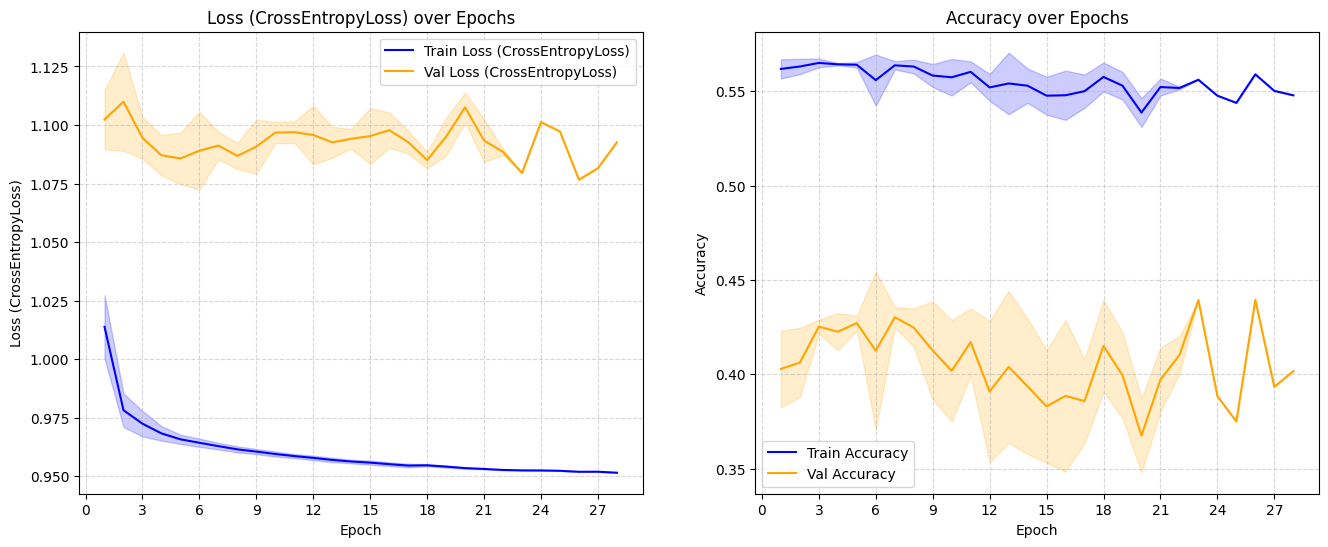

In [16]:
hgt_model = HGTModel(
    data=data,
    col_stats_dict=col_stats_dict,
    in_channels=in_channels,
    gnn_config=config["gnn_heads"]["hgt"],
    mlp_config=mlp_config,
    task_type=task_type,
    dropout=dropout
).to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(hgt_model.parameters(), lr=learning_rate)

trainer = Trainer(
    task=task,
    model=hgt_model,
    optimizer=optimizer,
    criterion=criterion,
    device=device
)

trainer.run_experiment(
    loader_dict,
    num_epochs,
    tune_metric="accuracy",
    higher_is_better=True,
    patience=10,
    print_every=3,
    num_runs=num_runs
)

# torch.save(best_weights, os.path.join(cache_dir, dataset_name, f"{hgt_model.gnn_name}_{task_name}_best_weights.pt"))

del hgt_model, optimizer, trainer
torch.cuda.empty_cache()
gc.collect()